# 平坦模型：AD-TLERT 时移反演

读取 `result/1_forward/0_flat_model` 中49个时刻的 `.dat` 观测，使用独立的电极位置驱动三角反演网格，完成 GPU/cuDSS 加速的 AD-TLERT 滑窗时移反演。

本 notebook 不复用正演的94×24规则网格；正演网格只用于生成合成数据和显示真值。反演结果写入 `result/2_inversion/0_flat_model/0_adtlert`。


## 1. 环境、路径与依赖

这里强制使用 CUDA 和 cuDSS。若 GPU 后端没有真正启用，后面的预热检查会直接报错，不会静默回退到 CPU。


In [1]:
from pathlib import Path
import json
import os
import sys
import time

os.environ.setdefault('ADTLERT_ENABLE_FLOAT64', '1')

cwd = Path.cwd().resolve()
root = next(path for path in (cwd, *cwd.parents) if (path / 'pyproject.toml').exists())
sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm
import numpy as np
import torch

from adtlert.inr.physics import prepare_cuda_forward
from adtlert.inversion import InversionConfig, ParameterizedERTForward2p5D, WindowedTimeLapseERTInversion
from adtlert.utils.progress import InversionProgressPrinter
from adtlert.workflows import build_source_position_triangle_inversion_case
from example.window_363.inversion_adtlert import (
    _build_forward_parameterization,
    _discover_forward_dat,
    _load_forward_series,
    _load_geometry,
    _save_mesh_npz,
)

torch.set_default_dtype(torch.float64)  # after adtlert fixed FLOAT_DTYPE at import

forward_dir = root / 'result/1_forward/0_flat_model'
truth_dir = root / 'data/test_model/0_flat_model'
truth_file = truth_dir / 'resistivity.npy'
metadata_file = truth_dir / 'metadata.json'
output_dir = root / 'result/2_inversion/0_flat_model/0_adtlert'
output_dir.mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), '本 notebook 强制要求 CUDA，但 torch.cuda.is_available() 为 False'
print('project root:', root)
print('forward data:', forward_dir)
print('output:', output_dir)
print('GPU:', torch.cuda.get_device_name(torch.cuda.current_device()))


project root: /home/luffy/projects/DeepERT
forward data: /home/luffy/projects/DeepERT/result/1_forward/0_flat_model
output: /home/luffy/projects/DeepERT/result/2_inversion/0_flat_model/0_adtlert
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. 集中设置反演参数

先建立一个可复现的传统 AD-TLERT 基线。时间窗只包含相邻3个时刻，既控制显存和运行时间，也避免一个窗口同时覆盖两个脉冲事件。后续调参只需修改本单元。


In [2]:
settings = {
    'window_size': 3,
    'window_step': 1,
    'max_iterations': 10,
    'spatial_regularization': 50.0,
    'temporal_regularization': 10.0,
    'spatial_regularization_type': 'first_order_smoothness',
    'temporal_regularization_type': 'temporal_smoothness',
    'optimizer': 'gauss_newton_cgls',
    'linearized_solver': 'gpu_cgls',
    'cgls_max_iterations': 60,
    'cgls_tolerance': 1.0e-10,
    'target_chi2': None,
    'step_tolerance': 1.0e-4,
    'model_bounds': (10.0, 1000.0),
    'coverage_percentile': 20.0,
    'mesh_quality': 34.0,
    'mesh_max_cell_area': 100.0,
    'mesh_smoothing_iterations': 10,
    'forward_refinement': 'native',
    'linear_solver_backend': 'cudss',
}
settings


{'window_size': 3,
 'window_step': 1,
 'max_iterations': 10,
 'spatial_regularization': 50.0,
 'temporal_regularization': 10.0,
 'spatial_regularization_type': 'first_order_smoothness',
 'temporal_regularization_type': 'temporal_smoothness',
 'optimizer': 'gauss_newton_cgls',
 'linearized_solver': 'gpu_cgls',
 'cgls_max_iterations': 60,
 'cgls_tolerance': 1e-10,
 'target_chi2': None,
 'step_tolerance': 0.0001,
 'model_bounds': (10.0, 1000.0),
 'coverage_percentile': 20.0,
 'mesh_quality': 34.0,
 'mesh_max_cell_area': 100.0,
 'mesh_smoothing_iterations': 10,
 'forward_refinement': 'native',
 'linear_solver_backend': 'cudss'}

## 3. 读取49个时刻的 `.dat` 观测与真值

`.dat` 是统一的观测输入；`forward_geometry.npz` 只提供公共几何。这里同时检查所有时刻的电极和测量排列是否一致。


In [3]:
pairs = _discover_forward_dat(
    forward_dir,
    file_stride=1,
    max_timesteps=None,
    selected_steps=None,
)
steps = np.asarray([step for step, _ in pairs], dtype=np.int32)
geometry = _load_geometry(forward_dir / 'forward_geometry.npz')
observed_rhoa, measurements, elec_x, elec_z, err, data_files, format_counts = _load_forward_series(
    pairs,
    forward_format='dat',
)
truth_models = np.asarray(np.load(truth_file, allow_pickle=False), dtype=np.float64)
metadata = json.loads(metadata_file.read_text(encoding='utf-8'))

assert steps.size == truth_models.shape[0] == 49
assert observed_rhoa.shape == (steps.size, measurements.shape[0])
assert np.all(np.isfinite(observed_rhoa)) and np.all(observed_rhoa > 0.0)
assert err is not None and err.shape == observed_rhoa.shape
assert tuple(truth_models.shape[1:]) == (len(geometry['layer_thickness']), len(geometry['x_nodes']) - 1)

data_std = np.log1p(err)
log_change_rms = 100.0 * np.sqrt(np.mean(np.log(observed_rhoa / observed_rhoa[0]) ** 2, axis=1))

print('timesteps:', steps[0], 'to', steps[-1], f'({steps.size} total)')
print('observed rhoa shape:', observed_rhoa.shape)
print('measurements per timestep:', measurements.shape[0])
print('input formats:', format_counts)
print('rhoa range:', float(observed_rhoa.min()), 'to', float(observed_rhoa.max()), 'ohm-m')
print('relative error:', float(np.median(err)))


timesteps: 0 to 48 (49 total)
observed rhoa shape: (49, 360)
measurements per timestep: 360
input formats: {'dat': 49}
rhoa range: 86.5010116878639 to 122.93358639795 ohm-m
relative error: 0.03


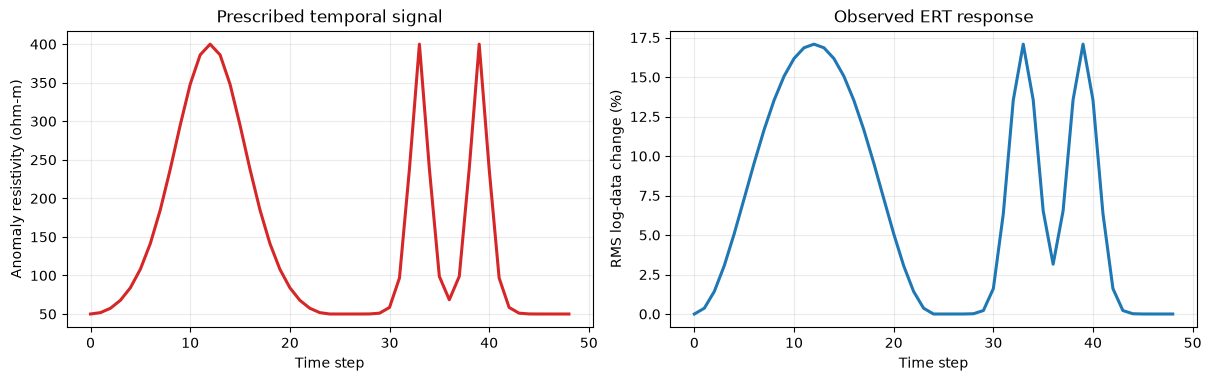

In [4]:
x_nodes = geometry['x_nodes']
layer_thickness = geometry['layer_thickness']
x_centers = 0.5 * (x_nodes[:-1] + x_nodes[1:])
depth_edges = np.concatenate(([0.0], np.cumsum(layer_thickness)))
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])

bounds = metadata['anomaly_bounds']
truth_anomaly_mask = (
    (x_centers[None, :] >= bounds['x_min'])
    & (x_centers[None, :] <= bounds['x_max'])
    & (depth_centers[:, None] >= bounds['depth_min'])
    & (depth_centers[:, None] <= bounds['depth_max'])
)
truth_anomaly_curve = np.median(truth_models[:, truth_anomaly_mask], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.7), constrained_layout=True)
axes[0].plot(steps, truth_anomaly_curve, color='#d62728', linewidth=2.2)
axes[0].set(xlabel='Time step', ylabel='Anomaly resistivity (ohm-m)', title='Prescribed temporal signal')
axes[0].grid(alpha=0.25)
axes[1].plot(steps, log_change_rms, color='#1f77b4', linewidth=2.2)
axes[1].set(xlabel='Time step', ylabel='RMS log-data change (%)', title='Observed ERT response')
axes[1].grid(alpha=0.25)
plt.show()


## 4. 单独建立三角形反演网格

反演网格只根据电极位置和测量装置生成，与正演的规则网格拓扑不同。`case.mesh` 是参数网格，`case.forward_mesh` 包含外部边界，用于反演过程中的正演求解。


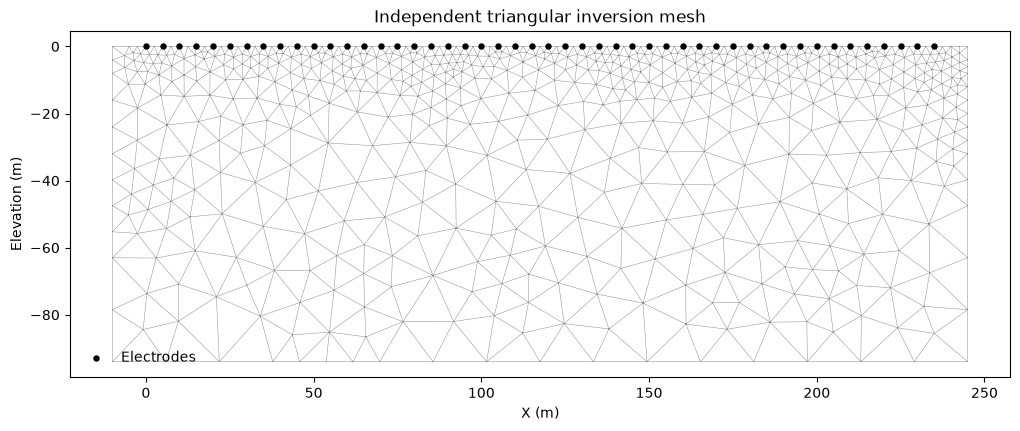

inversion parameter cells: 1126
inversion mesh nodes: 636
full forward cells: 1768
synthetic forward cells: 2256


In [5]:
case = build_source_position_triangle_inversion_case(
    elec_x,
    elec_z,
    measurements,
    geometry['x_nodes'],
    geometry['z_top'],
    geometry['layer_thickness'],
    y_index=0,
    quality=settings['mesh_quality'],
    parameter_max_cell_area=settings['mesh_max_cell_area'],
    smoothing_iterations=settings['mesh_smoothing_iterations'],
    data_file=pairs[0][1],
)
assert observed_rhoa.shape[1] == case.survey.measurement_count
assert case.mesh.cell_count != truth_models.shape[1] * truth_models.shape[2], '反演网格不应等于正演规则网格'

mesh_nodes = np.asarray(case.mesh.nodes, dtype=float)
mesh_cells = np.asarray(case.mesh.cells, dtype=np.int32)
fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
ax.triplot(mesh_nodes[:, 0], mesh_nodes[:, 1], mesh_cells, color='0.55', linewidth=0.35)
ax.scatter(elec_x, elec_z, s=13, c='black', zorder=3, label='Electrodes')
ax.set(xlabel='X (m)', ylabel='Elevation (m)', title='Independent triangular inversion mesh')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False)
fig.savefig(output_dir / 'inversion_mesh.png', dpi=180, bbox_inches='tight')
plt.show()

print('inversion parameter cells:', case.mesh.cell_count)
print('inversion mesh nodes:', case.mesh.node_count)
print('full forward cells:', case.forward_mesh.cell_count)
print('synthetic forward cells:', truth_models.shape[1] * truth_models.shape[2])


## 5. 创建 AD-TLERT 正演算子并强制验证 GPU/cuDSS

先以初始模型预热稀疏求解器，复用符号分解和 GPU 缓冲。只有 `cudss_gpu_enabled=True` 才继续反演。


In [6]:
if 'forward' in globals():
    try:
        forward.close()
    except Exception:
        pass

forward_mesh, parameter_cell_ids, forward_cell_parameter_ids, forward_parent_cell_ids = _build_forward_parameterization(
    case,
    settings['forward_refinement'],
)
forward = ParameterizedERTForward2p5D.from_mesh_survey(
    forward_mesh,
    case.survey,
    parameter_cell_ids,
    regularization_mesh=case.mesh,
    forward_cell_parameter_ids=forward_cell_parameter_ids,
    linear_solver_backend=settings['linear_solver_backend'],
    normal_field_cache_max_entries=8,
)

initial_resistivity = 100.0

initial_model = np.full(
    (case.mesh.cell_count, observed_rhoa.shape[0]),
    initial_resistivity,
    dtype=np.float64,
)
gpu_report = prepare_cuda_forward(
    forward,
    np.log(initial_model[:, 0]),
    require_cuda=True,
    device='cuda',
)
assert gpu_report['cudss_gpu_enabled'], gpu_report
print(json.dumps(gpu_report, indent=2))


{
  "network_cuda_available": true,
  "linear_solver_backend": "cudss",
  "cudss_gpu_enabled": true,
  "cudss_zero_copy": false,
  "gpu_device_index": 0,
  "gpu_name": "NVIDIA GeForce RTX 5060 Laptop GPU"
}


## 6. 配置并运行滑窗时移反演

外层为 Gauss–Newton，线性化子问题使用 GPU CGLS。空间和时间正则化都作用于对数电阻率状态；当前合成数据未加入随机噪声，因此取消 `target_chi2` 停止条件，改由步长阈值或最大迭代次数停止。


In [7]:
progress = InversionProgressPrinter(enabled=True)
config = InversionConfig(
    max_iterations=settings['max_iterations'],
    data_std=data_std,
    data_misfit='weighted_log_l2',
    regularization=settings['spatial_regularization'],
    regularization_mode='model',
    regularization_domain='state',
    temporal_regularization=settings['temporal_regularization'],
    temporal_regularization_type=settings['temporal_regularization_type'],
    spatial_regularization=settings['spatial_regularization_type'],
    petrophysical_transform='log_resistivity',
    optimization_algorithm=settings['optimizer'],
    linearized_solver=settings['linearized_solver'],
    cgls_max_iterations=settings['cgls_max_iterations'],
    cgls_tolerance=settings['cgls_tolerance'],
    target_chi2=settings['target_chi2'],
    step_tolerance=settings['step_tolerance'],
    model_bounds=settings['model_bounds'],
    max_log_step=1.0,
    line_search=True,
    normal_sensitivity=True,
    progress_callback=progress,
)

started = time.perf_counter()
try:
    inversion = WindowedTimeLapseERTInversion(
        forward=forward,
        observed_data=observed_rhoa,
        config=config,
        window_size=settings['window_size'],
        window_step=settings['window_step'],
    ).setup()
    result = inversion.run(initial_model)
finally:
    forward.close()
    progress.finish()
elapsed_seconds = time.perf_counter() - started

print(f'elapsed: {elapsed_seconds:.3f} s ({elapsed_seconds / 60.0:.3f} min)')
print('final model shape:', result.final_models.shape)
print('windows:', len(result.window_reports))


Windowed inversion: 47 windows, window_size=3, window_step=1, max_iterations=10
Windowed [#...........................] window 1/47 done: steps 0-2, chi2=0.03044
Windowed [#...........................] window 2/47 done: steps 1-3, chi2=0.02163
Windowed [##..........................] window 3/47 done: steps 2-4, chi2=0.01177
Windowed [##..........................] window 4/47 done: steps 3-5, chi2=0.005005
Windowed [###.........................] window 5/47 done: steps 4-6, chi2=0.003744
Windowed [####........................] window 6/47 done: steps 5-7, chi2=0.008886
Windowed [####........................] window 7/47 done: steps 6-8, chi2=0.02086
Windowed [#####.......................] window 8/47 done: steps 7-9, chi2=0.03951
Windowed [#####.......................] window 9/47 done: steps 8-10, chi2=0.0627
Windowed [######......................] window 10/47 done: steps 9-11, chi2=0.08575
Windowed [#######.....................] window 11/47 done: steps 10-12, chi2=0.1028
Windowed [#

elapsed: 75.516 s (1.259 min)
final model shape: (1126, 49)
windows: 47


## 7. 保存反演结果

只保存合并后的时移数组、独立反演网格和诊断量，避免为49个时刻再复制49份小文件。


In [8]:
final_models = np.asarray(result.final_models, dtype=np.float64)
final_log_models = np.asarray(result.final_log_models, dtype=np.float64)
predicted_rhoa = np.asarray(result.predicted_data, dtype=np.float64)
coverage = np.asarray(result.coverage, dtype=np.float64).ravel()
coverage_threshold = float(np.percentile(coverage, settings['coverage_percentile']))
coverage_mask = coverage < coverage_threshold
window_chi2 = np.asarray(result.all_chi2, dtype=np.float64)
weighted_log_residual = (np.log(predicted_rhoa) - np.log(observed_rhoa)) / data_std
chi2_by_time = np.mean(weighted_log_residual**2, axis=1)

np.save(output_dir / 'final_models.npy', final_models)
np.save(output_dir / 'final_log_models.npy', final_log_models)
np.save(output_dir / 'predicted_rhoa.npy', predicted_rhoa)
np.save(output_dir / 'steps.npy', steps)
np.save(output_dir / 'window_chi2.npy', window_chi2)
np.save(output_dir / 'chi2_by_time.npy', chi2_by_time)
np.save(output_dir / 'coverage.npy', coverage)
np.save(output_dir / 'coverage_mask.npy', coverage_mask.astype(np.uint8))
_save_mesh_npz(
    output_dir / 'timelapse_inversion_mesh.npz',
    case,
    forward_mesh=forward_mesh,
    parameter_cell_ids=parameter_cell_ids,
    forward_cell_parameter_ids=forward_cell_parameter_ids,
    forward_parent_cell_ids=forward_parent_cell_ids,
)
(output_dir / 'used_data_files.txt').write_text(
    ''.join(f'{path}\n' for path in data_files),
    encoding='utf-8',
)
(output_dir / 'window_reports.json').write_text(
    json.dumps(result.window_reports, indent=2),
    encoding='utf-8',
)

summary = {
    'engine': 'AD-TLERT',
    'inversion_mode': 'windowed',
    'n_timesteps': int(steps.size),
    'first_step': int(steps[0]),
    'last_step': int(steps[-1]),
    'n_measurements_per_timestep': int(observed_rhoa.shape[1]),
    'n_inversion_cells': int(case.mesh.cell_count),
    'n_forward_cells': int(forward_mesh.cell_count),
    'input_format': 'dat',
    'input_dir': str(forward_dir),
    'truth_file': str(truth_file),
    'output_dir': str(output_dir),
    'mesh_is_independent_from_synthetic_grid': True,
    'window_size': int(settings['window_size']),
    'window_step': int(settings['window_step']),
    'n_windows': int(len(result.window_reports)),
    'max_iterations': int(settings['max_iterations']),
    'spatial_regularization': float(settings['spatial_regularization']),
    'temporal_regularization': float(settings['temporal_regularization']),
    'spatial_regularization_type': settings['spatial_regularization_type'],
    'temporal_regularization_type': settings['temporal_regularization_type'],
    'optimizer': settings['optimizer'],
    'linearized_solver': settings['linearized_solver'],
    'target_chi2': settings['target_chi2'],
    'coverage_percentile': float(settings['coverage_percentile']),
    'mesh_max_cell_area': float(settings['mesh_max_cell_area']),
    'coverage_threshold': coverage_threshold,
    'mean_chi2': float(np.mean(chi2_by_time)),
    'median_chi2': float(np.median(chi2_by_time)),
    'max_chi2': float(np.max(chi2_by_time)),
    'elapsed_seconds': float(elapsed_seconds),
    'seconds_per_timestep': float(elapsed_seconds / steps.size),
    'gpu': gpu_report,
}
(output_dir / 'inversion_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary, indent=2))


{
  "engine": "AD-TLERT",
  "inversion_mode": "windowed",
  "n_timesteps": 49,
  "first_step": 0,
  "last_step": 48,
  "n_measurements_per_timestep": 360,
  "n_inversion_cells": 1126,
  "n_forward_cells": 1768,
  "input_format": "dat",
  "input_dir": "/home/luffy/projects/DeepERT/result/1_forward/0_flat_model",
  "truth_file": "/home/luffy/projects/DeepERT/data/test_model/0_flat_model/resistivity.npy",
  "output_dir": "/home/luffy/projects/DeepERT/result/2_inversion/0_flat_model/0_adtlert",
  "mesh_is_independent_from_synthetic_grid": true,
  "window_size": 3,
  "window_step": 1,
  "n_windows": 47,
  "max_iterations": 10,
  "spatial_regularization": 50.0,
  "temporal_regularization": 10.0,
  "spatial_regularization_type": "first_order_smoothness",
  "temporal_regularization_type": "temporal_smoothness",
  "optimizer": "gauss_newton_cgls",
  "linearized_solver": "gpu_cgls",
  "target_chi2": null,
  "coverage_percentile": 20.0,
  "mesh_max_cell_area": 100.0,
  "coverage_threshold": -2.40

## 9. 真值—反演快照与时间曲线

快照使用统一色标。时间曲线比较矩形异常体内部的真值与反演中位数，直接检查慢变化和两个快速事件是否被恢复。


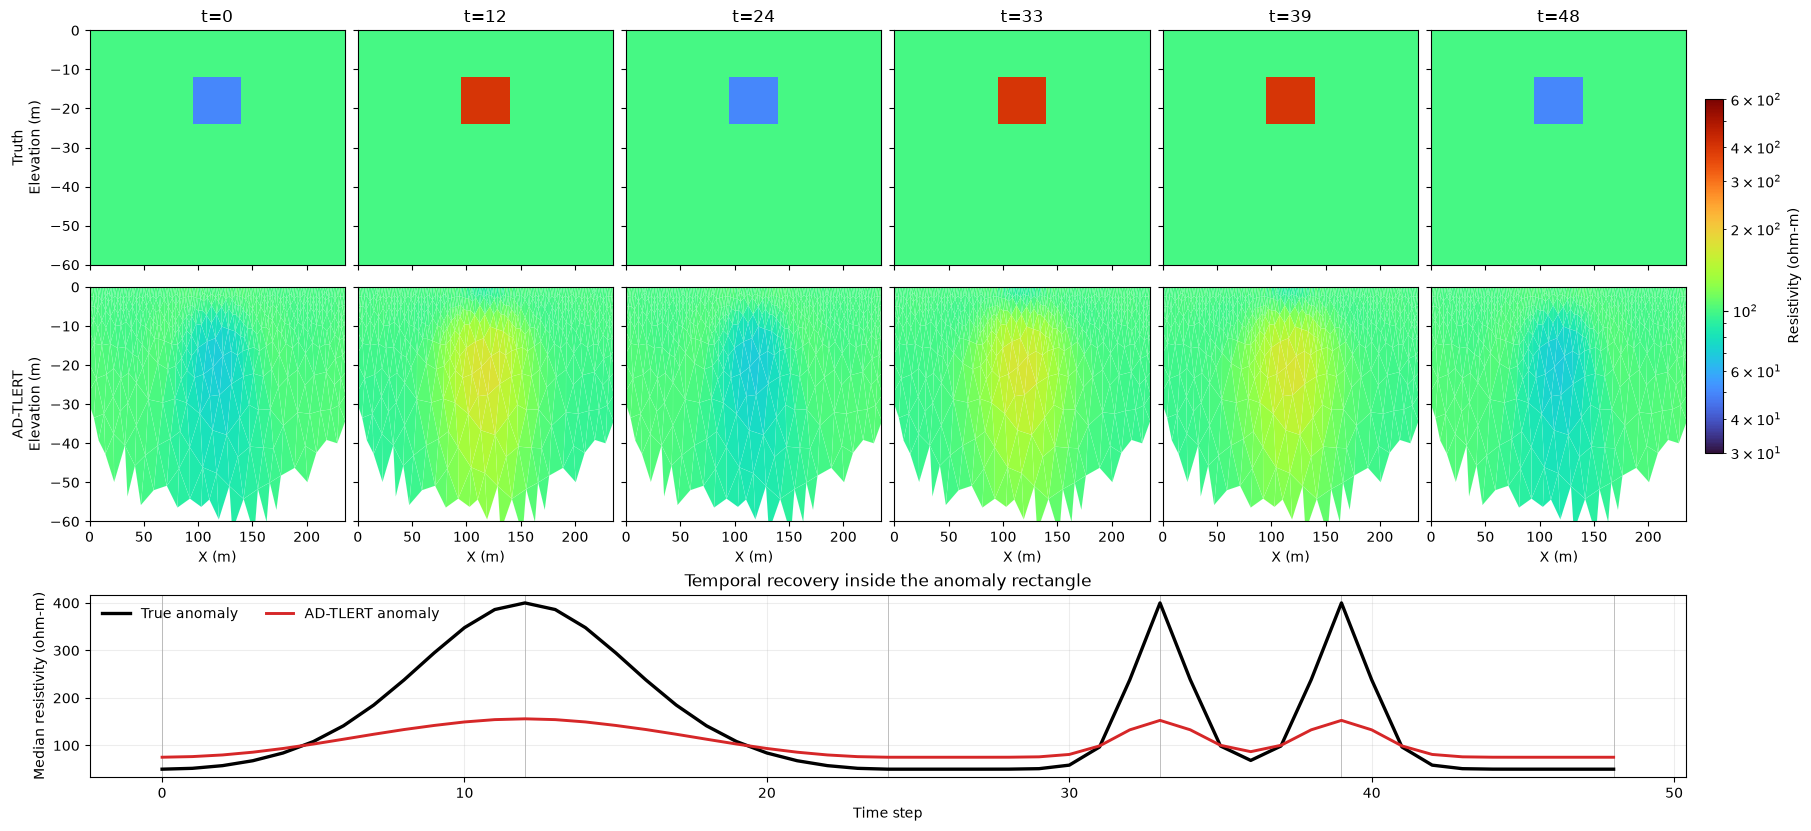

In [9]:
centers = mesh_nodes[mesh_cells].mean(axis=1)
surface_at_cells = np.interp(centers[:, 0], geometry['x_nodes'], geometry['z_top'])
cell_depth = surface_at_cells - centers[:, 1]
inverted_anomaly_mask = (
    (centers[:, 0] >= bounds['x_min'])
    & (centers[:, 0] <= bounds['x_max'])
    & (cell_depth >= bounds['depth_min'])
    & (cell_depth <= bounds['depth_max'])
    & (~coverage_mask)
)
assert np.any(inverted_anomaly_mask), '覆盖度筛选后异常区域没有反演单元'
inverted_anomaly_curve = np.median(final_models[inverted_anomaly_mask, :], axis=0)

selected_steps = [0, 12, 24, 33, 39, 48]
selected_indices = [int(np.flatnonzero(steps == step)[0]) for step in selected_steps]
norm = LogNorm(vmin=30.0, vmax=600.0)
cmap = 'turbo'

cumulative_depth = np.concatenate(([0.0], np.cumsum(geometry['layer_thickness'])))
x_grid = np.tile(geometry['x_nodes'], (cumulative_depth.size, 1))
z_grid = geometry['z_top'][None, :] - cumulative_depth[:, None]

fig = plt.figure(figsize=(18, 8.2), constrained_layout=True)
grid_spec = fig.add_gridspec(3, len(selected_steps), height_ratios=[1.0, 1.0, 0.78])
for column, (step, time_index) in enumerate(zip(selected_steps, selected_indices, strict=True)):
    ax_true = fig.add_subplot(grid_spec[0, column])
    ax_inv = fig.add_subplot(grid_spec[1, column], sharex=ax_true, sharey=ax_true)
    ax_true.pcolormesh(x_grid, z_grid, truth_models[time_index], shading='auto', cmap=cmap, norm=norm)
    inv_values = final_models[:, time_index].copy()
    inv_values[coverage_mask] = np.nan
    visible = np.isfinite(inv_values)
    collection = PolyCollection(
        mesh_nodes[mesh_cells][visible],
        array=inv_values[visible],
        cmap=cmap,
        norm=norm,
        edgecolors=(1, 1, 1, 0.20),
        linewidths=0.18,
    )
    ax_inv.add_collection(collection)
    ax_true.set_title(f't={step}')
    if column == 0:
        ax_true.set_ylabel('Truth\nElevation (m)')
        ax_inv.set_ylabel('AD-TLERT\nElevation (m)')
    else:
        ax_true.tick_params(labelleft=False)
        ax_inv.tick_params(labelleft=False)
    ax_true.tick_params(labelbottom=False)
    ax_inv.set_xlabel('X (m)')
    for ax in (ax_true, ax_inv):
        ax.set_xlim(float(geometry['x_nodes'].min()), float(geometry['x_nodes'].max()))
        ax.set_ylim(float(z_grid.min()), float(z_grid.max()))

ax_curve = fig.add_subplot(grid_spec[2, :])
ax_curve.plot(steps, truth_anomaly_curve, color='black', linewidth=2.4, label='True anomaly')
ax_curve.plot(steps, inverted_anomaly_curve, color='#d62728', linewidth=2.1, label='AD-TLERT anomaly')
for step in selected_steps:
    ax_curve.axvline(step, color='0.75', linewidth=0.7, zorder=0)
ax_curve.set(xlabel='Time step', ylabel='Median resistivity (ohm-m)', title='Temporal recovery inside the anomaly rectangle')
ax_curve.grid(alpha=0.22)
ax_curve.legend(frameon=False, ncol=2)

colorbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=fig.axes[:-1], shrink=0.72, pad=0.012)
colorbar.set_label('Resistivity (ohm-m)')
fig.savefig(output_dir / 'model_and_temporal_recovery.png', dpi=180, bbox_inches='tight')
plt.show()


## 10. 输出文件

`final_models.npy` 的形状为 `(反演单元数, 49)`；后续 INR 与 PyGIMLi 结果应统一映射到这个独立反演网格或统一的评价采样点后再比较。


In [10]:
for path in sorted(output_dir.iterdir()):
    print(f'{path.name:36s} {path.stat().st_size:>12d} bytes')


chi2_by_time.npy                              520 bytes
coverage.npy                                 9136 bytes
coverage_mask.npy                            1254 bytes
final_log_models.npy                       441520 bytes
final_models.npy                           441520 bytes
inversion_mesh.png                         499325 bytes
inversion_summary.json                       1442 bytes
model_and_temporal_recovery.png            998691 bytes
predicted_rhoa.npy                         141248 bytes
steps.npy                                     324 bytes
timelapse_inversion_mesh.npz               115920 bytes
used_data_files.txt                          4802 bytes
window_chi2.npy                               504 bytes
window_reports.json                          7160 bytes
